# Project: Vinyl Record Collection Data Exploration

## Step 1: Extracting the data

I have a modest collection of vinyl records and I'd like to explore it a bit. I am going to use the discogs API to access my collection directly. I can use the 'requests' library to do this.

In [1]:
import requests

In order to access MY collection, I need to define my username and generate a user token so that the API knows to identify me when I call it. The user token is generated on the discogs website.

In [2]:
# set up variables
USERNAME = 'shwigwam'
USER_TOKEN = 'EsaivqcDtkMzZOmdnMEvHJIqOAfZdIAAevSwgbhz'

When I send my API request, I would like my information in a specific way. I can use HTTP request headers to do this for me. I will give it the name of my app (VinylDatabase), and create a 1.0 directory within it for version control. This is also where I will feed my user token, telling discogs that I have been granted permission to do this.

In [3]:
headers = {
    'User-Agent': 'VinylDatabase/1.0',
    'Authorization': f'Discogs token={USER_TOKEN}'
}

I also need to point to my collection. Here I will define base_url to do this.

In [4]:
base_url = f'https://api.discogs.com/users/{USERNAME}/collection/folders/0/releases'

Now we can grab the information we want. To do this, we use get function from the requests library, feeding it our variables and such as instructions. To make it parseable for our needs, we will convert this data to .json format. You could also convert it to a text format.

In [5]:
params = {'per_page': 100, 'page': 1}

response = requests.get(base_url, headers=headers, params=params)
data = response.json()

Lets see what our dictionary looks like. We can get a quick idea by looking at the keys.

In [6]:
data.keys()

dict_keys(['pagination', 'releases'])

We have two keys: pagination and releases. The former will likely contain information relating to the page we are on and the number of items within. The latter will likely contain the real data we are looking for.

In [7]:
print(data['pagination'])

{'page': 1, 'pages': 2, 'per_page': 100, 'items': 198, 'urls': {'last': 'https://api.discogs.com/users/shwigwam/collection/folders/0/releases?page=2&per_page=100&sort=label&sort_order=asc', 'next': 'https://api.discogs.com/users/shwigwam/collection/folders/0/releases?page=2&per_page=100&sort=label&sort_order=asc'}}


We can use the pagination key to loop through our pages and extract the data we need from the releases variable. Before we do that, we want to look at what information the releases key actually contains so we know what to extract. Let's look at the first result.

In [8]:
data['releases'][0]

{'id': 4619543,
 'instance_id': 101956297,
 'date_added': '2013-09-27T00:46:29-07:00',
 'rating': 0,
 'basic_information': {'id': 4619543,
  'master_id': 437190,
  'master_url': 'https://api.discogs.com/masters/437190',
  'resource_url': 'https://api.discogs.com/releases/4619543',
  'thumb': 'https://i.discogs.com/VPElaoQC8SVCduYOVIjBHlthfRWs0KyFHzfGRtDG7Ms/rs:fit/g:sm/q:40/h:150/w:150/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTQ2MTk1/NDMtMTM3Njc4NTI1/NC01MTM2LmpwZWc.jpeg',
  'cover_image': 'https://i.discogs.com/oPacEC53piSn6x_Ooh5dB59DC0MsUHe0VKkzi3_y60I/rs:fit/g:sm/q:90/h:593/w:593/czM6Ly9kaXNjb2dz/LWRhdGFiYXNlLWlt/YWdlcy9SLTQ2MTk1/NDMtMTM3Njc4NTI1/NC01MTM2LmpwZWc.jpeg',
  'title': 'Joyce Manor / Summer Vacation',
  'year': 2012,
  'formats': [{'name': 'Vinyl',
    'qty': '1',
    'text': 'Pink',
    'descriptions': ['7"', '33 ⅓ RPM', 'Repress']}],
  'labels': [{'name': '¡Muy Auténtico Records!',
    'catno': 'MAR-006',
    'entity_type': '1',
    'entity_type_name': 'Label',
    '

We are getting a lot of metadata. Everything we want is within the 'basic_information' key, so lets dig into there to extract the following: title, year, formats, labels, artists, genres, styles, format.

Some things we need to keep in mind: 

1. Some releases are splits containing multiple artists. Some also have multiple genres, styles, labels, etc. We will need to collect these into their own list of sorts and separate them by commas.
2. We can use the 'page' variable to iterate through each page we have.

In [9]:
all_releases = []

while True:
    response = requests.get(base_url, headers=headers, params=params)
    data = response.json()
    
    for item in data['releases']:
        artists = item['basic_information'].get('artists', [])
        artist_names = ', '.join(artist['name'] for artist in artists)
        
        all_releases.append({
            #'artist': ', '.join(artist['name'] for artist in item['basic_information']['artists']),
            'artist': artist_names,
            'title': item['basic_information']['title'],
            'year': item['basic_information'].get('year'),
            'label': ', '.join(l['name'] for l in item['basic_information'].get('labels', [])),
            'genres': ', '.join(item['basic_information'].get('genres', [])),
            'styles': ', '.join(item['basic_information'].get('styles', [])) if 'styles' in item['basic_information'] else None,
            'format': ', '.join(f['name'] for f in item['basic_information'].get('formats', [])),
            'catno': ', '.join(f['catno'] for f in item['basic_information'].get('labels', [])),
            'is_split': len(artists) > 1
            
        })

    if data['pagination']['pages'] > params['page']:
        params['page'] += 1
    else:
        break

print(f"Total records retrieved: {len(all_releases)}")

Total records retrieved: 198


## Step 2: Cleaning the data

Now that we have what we need, let's convert it into a dataframe so it is easier to work with.

In [10]:
import pandas as pd

df = pd.DataFrame(all_releases)
df.columns = [col.capitalize() for col in df.columns]
df

,Artist,Title,Year,Label,Genres,Styles,Format,Catno,Is_split
0,"Joyce Manor, Summer Vacation",Joyce Manor / Summer Vacation,2012,"¡Muy Auténtico Records!, Lauren Records (2)",Rock,Punk,Vinyl,"MAR-006, LR#9",True
1,Foxes,The Kick,2022,[pias],Pop,,Vinyl,PIASR5089LP,False
2,Lycus,Tempest,2013,20 Buck Spin,Rock,"Death Metal, Funeral Doom Metal",Vinyl,SPIN055,False
3,Joyce Manor,Joyce Manor,2012,6131 Records,Rock,Punk,Vinyl,6131027,False
4,Touché Amoré,...To The Beat Of A Dead Horse,2011,"6131 Records, Collect Records",Rock,Hardcore,Vinyl,"6131019, none",False
...,...,...,...,...,...,...,...,...,...
193,Boards Of Canada,Tomorrow's Harvest,2013,"Warp Records, Music70",Electronic,"Downtempo, Ambient, IDM",Vinyl,"WARPLP257, WARPLP257",False
194,Boards Of Canada,Twoism,2013,"Warp Records, Music70",Electronic,"IDM, Ambient",Vinyl,"WARPLP70R, WARPLP70R",False
195,Boards Of Canada,Music Has The Right To Children,2013,"Warp Records, Skam",Electronic,"IDM, Ambient",Vinyl,"warplp55r, skalp 1",False
196,Swans,The Seer,2012,Young God Records,Rock,"Experimental, Noise Rock",Vinyl,YG45,False


There are a few more cleaning steps needed here. They may not be evident, but because this is my collection, I know they are a problem.

1. Removing unintended spaces at the end of strings (this can happen with some discogs data).
2. Relabeling albums that share the same name.
3. Removing the (#) after some artist names stemming from discogs having multiple artists with the same name.

In [11]:
# removing trailing spaces
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].str.strip()
    
# addressing some cases where all albums from the same artist share the same name    
df.loc[(df['Title'] == 'American Football') & (df['Year'] < 2016), 'Title'] = 'American Football (LP1)'
df.loc[(df['Title'] == 'American Football') & (df['Year'] == 2016), 'Title'] = 'American Football (LP2)'
df.loc[(df['Title'] == 'American Football') & (df['Year'] > 2016), 'Title'] = 'American Football (LP3)'

df.loc[(df['Title'] == 'Everyone Everywhere') & (df['Year'] == 2011), 'Title'] = 'Everyone Everywhere (LP1)'
df.loc[(df['Title'] == 'Everyone Everywhere') & (df['Year'] == 2012), 'Title'] = 'Everyone Everywhere (LP2)'

# removing the (#) after some artist names
df['Artist'] = df['Artist'].str.replace(r'\s*\(\d+\)$', '', regex=True)

These are hard-coded solutions for specific releases. I could write something that automates this for any duplicate release, however, some of the duplicate releases are represses of the same record, and because discogs does not provide the formal initial release date for the album (only the release date of that particular pressing), it would be get complicated to find a workaround that distinguishes between repress and the next album release.

## Step 3: Additional data

Before we dig in, I am going to introduce some additional data here that could be interesting. I created a simple table that contains information about each artist's location of orgin. We can join this to our data above.

In [12]:
locations_path = '/Users/Nadim/Documents/Python/Vinyl dataset - Locations.csv'
locations = pd.read_csv(locations_path)

df_with_locs = pd.merge(df,locations, how='outer', on='Artist')

One more thing: the year column in our dataset refers to the year the vinyl record itself was pressed and released. Since vinyl records often get represses many years after the original release, we aren't actually sure if these numbers reflect the actual release date. I am introducing some more data that reflects the actual release date.

In [13]:
release_path = '/Users/Nadim/Documents/Python/Vinyl dataset - release date.csv'
release_dates = pd.read_csv(release_path)
release_dates = release_dates[["Title","Album Release Date"]]

df_final = pd.merge(df_with_locs, release_dates, how='outer', on='Title')

df_final

,Artist,Title,Year,Label,Genres,Styles,Format,Catno,Is_split,City,State,Country,Album Release Date
0,"Joyce Manor, Summer Vacation",Joyce Manor / Summer Vacation,2012.0,"¡Muy Auténtico Records!, Lauren Records (2)",Rock,Punk,Vinyl,"MAR-006, LR#9",True,NaN,NaN,NaN,2010.0
1,Foxes,The Kick,2022.0,[pias],Pop,,Vinyl,PIASR5089LP,False,Southampton,-,UK,2022.0
2,Lycus,Tempest,2013.0,20 Buck Spin,Rock,"Death Metal, Funeral Doom Metal",Vinyl,SPIN055,False,Oakland,CA,USA,2013.0
3,Joyce Manor,Joyce Manor,2012.0,6131 Records,Rock,Punk,Vinyl,6131027,False,Torrance,CA,USA,2011.0
4,Joyce Manor,Of All Things I Will Soon Grow Tired,2012.0,Asian Man Records,Rock,"Alternative Rock, Punk, Pop Rock",Vinyl,AMR236,False,Torrance,CA,USA,2012.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,The Flatliners,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Richmond Hill,ON,Canada,NaN
200,Tiny Empires,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Tampa,FL,USA,NaN
201,La Dispute,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grand Rapids,MI,USA,NaN
202,The Caskey Lottery,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Kansas City,MO,USA,NaN


## Step 4: Exploring the data

In [14]:
min_year = df_final['Album Release Date'].min()
max_year = df_final['Album Release Date'].max()

print("Your collection ranges between " + str(min_year) + " and " + str(max_year) + 
      ", which covers " + str(max_year - min_year) + " years overall.")

Your collection ranges between 1972.0 and 2022.0, which covers 50.0 years overall.


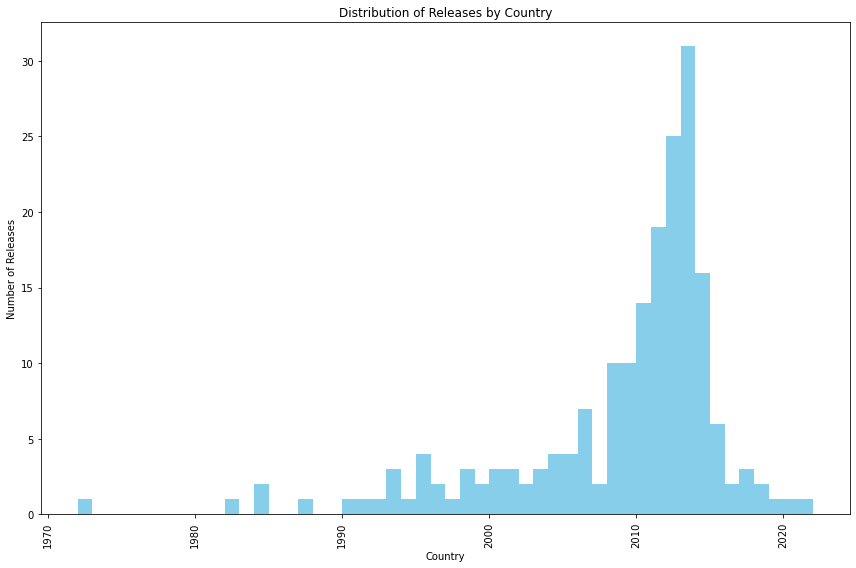

In [15]:
import matplotlib.pyplot as plt

df_final_no_title_dupes = df_final.drop_duplicates(subset=['Title'])
#df_final_no_title_dupes['Album Release Date'].hist(bins=50)

plt.figure(figsize=(12, 8))
df_final_no_title_dupes['Album Release Date'].plot(kind='hist', color='skyblue', bins=50)

# Adding labels and title
plt.xlabel('Country')
plt.ylabel('Number of Releases')
plt.title('Distribution of Releases by Country')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()

Looks like most of my releases are in the early 2010s. Makes sense, I started collecting them around this time.

I'm going to explore genres. Since we have both Genres and Styles (subgenres, bascially), I'm going to treat them separately. I am also going to break these apart because some releases have multiple genres/subgenres assigned to them.

In [16]:
df_final_no_artist_dupes = df_final.drop_duplicates(subset=['Artist'])

genre_spread = df_final_no_artist_dupes.copy()

#genre_spread['Genres'] = genre_spread['Genres'].str.split(',')
#genre_spread['Styles'] = genre_spread['Styles'].str.split(',')

genre_spread['Genres'] = genre_spread['Genres'].str.split(r',|&')
genre_spread['Styles'] = genre_spread['Styles'].str.split(r',|&')

genre_spread['Genres'] = genre_spread['Genres'].fillna('')
genre_spread['Styles'] = genre_spread['Styles'].fillna('')

genre_spread

,Artist,Title,Year,Label,Genres,Styles,Format,Catno,Is_split,City,State,Country,Album Release Date
0,"Joyce Manor, Summer Vacation",Joyce Manor / Summer Vacation,2012.0,"¡Muy Auténtico Records!, Lauren Records (2)",[Rock],[Punk],Vinyl,"MAR-006, LR#9",True,NaN,NaN,NaN,2010.0
1,Foxes,The Kick,2022.0,[pias],[Pop],[],Vinyl,PIASR5089LP,False,Southampton,-,UK,2022.0
2,Lycus,Tempest,2013.0,20 Buck Spin,[Rock],"[Death Metal, Funeral Doom Metal]",Vinyl,SPIN055,False,Oakland,CA,USA,2013.0
3,Joyce Manor,Joyce Manor,2012.0,6131 Records,[Rock],[Punk],Vinyl,6131027,False,Torrance,CA,USA,2011.0
6,Touché Amoré,...To The Beat Of A Dead Horse,2011.0,"6131 Records, Collect Records",[Rock],[Hardcore],Vinyl,"6131019, none",False,Los Angeles,CA,USA,2009.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
199,The Flatliners,NaN,NaN,NaN,,,NaN,NaN,NaN,Richmond Hill,ON,Canada,NaN
200,Tiny Empires,NaN,NaN,NaN,,,NaN,NaN,NaN,Tampa,FL,USA,NaN
201,La Dispute,NaN,NaN,NaN,,,NaN,NaN,NaN,Grand Rapids,MI,USA,NaN
202,The Caskey Lottery,NaN,NaN,NaN,,,NaN,NaN,NaN,Kansas City,MO,USA,NaN


In [17]:
genre_spread['Genres'] = genre_spread['Genres'].apply(lambda x: [i.strip() for i in x])
genre_spread['Styles'] = genre_spread['Styles'].apply(lambda x: [i.strip() for i in x])

In [18]:
genre_counts = genre_spread['Genres'].explode().value_counts()
style_counts = genre_spread['Styles'].explode().value_counts()

In [19]:
genre_counts

Rock          101
Electronic     16
Pop             6
Folk            2
                2
Country         2
World           2
Blues           1
Hip Hop         1
Classical       1
Name: Genres, dtype: int64

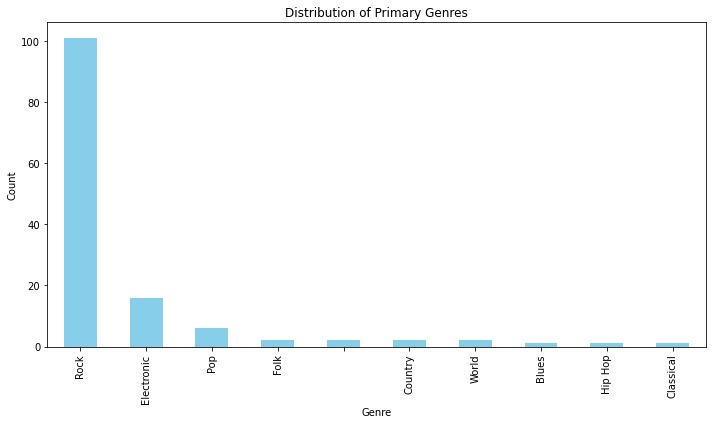

In [20]:
# Plot the genre distribution
plt.figure(figsize=(10, 6))
genre_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Primary Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Rock music is so broad that it really doesn't help to just rely on that descriptor alone. We'll see how much things change once we get into subgenres. Also, record stores have tiny sections for electronic music. I think I'd have a lot more in my collection if I could find them! Anyway, let's look at subgenres.

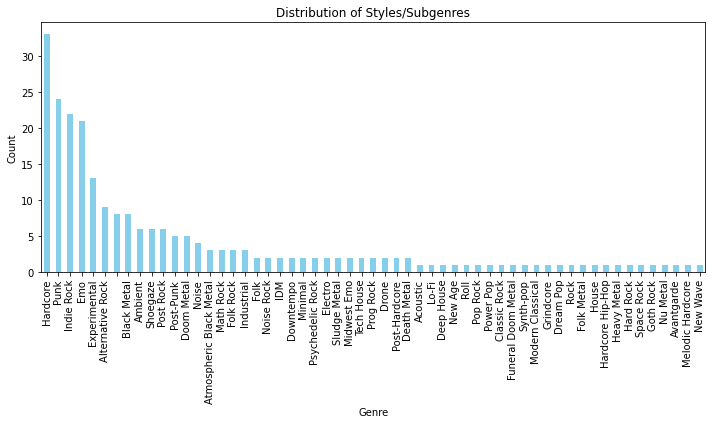

In [21]:
# Plot the genre distribution
plt.figure(figsize=(10, 6))
style_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Styles/Subgenres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

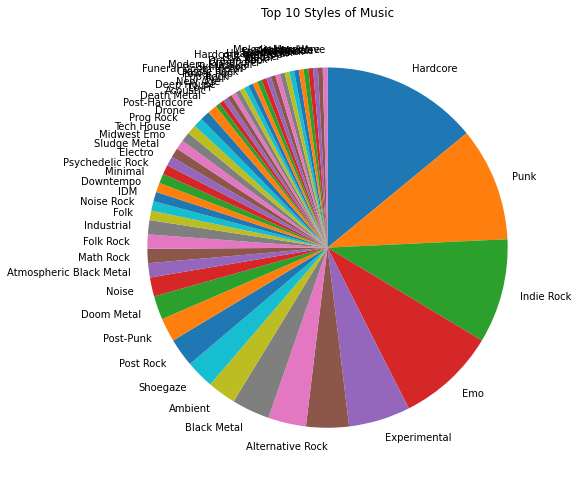

In [22]:
top_n = 10
style_counts_top = style_counts.head(top_n)

# Plot
plt.figure(figsize=(8, 8))
style_counts.plot.pie(startangle=90, counterclock=False)
plt.title(f"Top {top_n} Styles of Music")
plt.ylabel('')  # Hide y-label
plt.tight_layout()
plt.show()

Now this is much more interesting. I'm not too surprised to see Hardcore/Punk near the top. These genres have historically managed to always release on the vinyl format, even in the 90s and 00s when the medium was out of style, so when you're out looking for them, you'd have a good chance to find a vinyl copy somewhere! 

There are some redundancies here. Hardcore is a style of punk rock, atmospheric black metal is a style of black metal, etc. But these distinctions don't matter too much here, we're still getting a good sense of my taste.

Let's take a look at the geographic distribution of my collection.

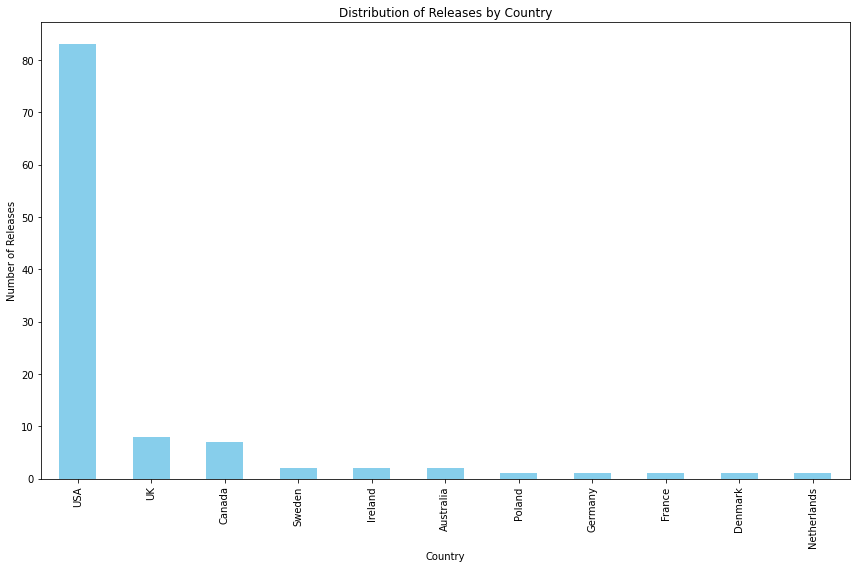

In [23]:
country_counts = df_final_no_artist_dupes['Country'].value_counts()

plt.figure(figsize=(12, 8))
country_counts.plot(kind='bar', color='skyblue')

# Adding labels and title
plt.xlabel('Country')
plt.ylabel('Number of Releases')
plt.title('Distribution of Releases by Country')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()

Most originate from the USA. Not surprising. Since most of our music originates from one country, let's dig into that location.

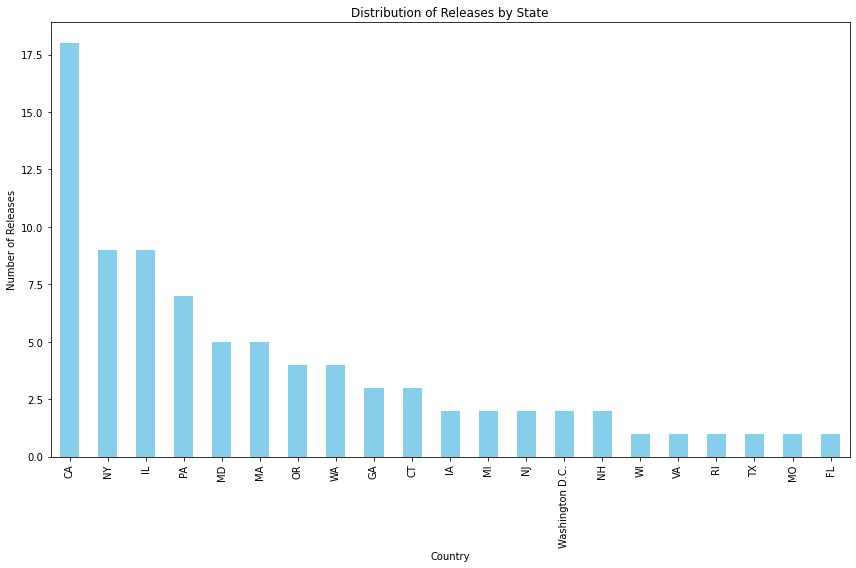

In [24]:
df_final_no_artist_dupes_USA = df_final_no_artist_dupes[df_final_no_artist_dupes['Country'] == 'USA']

state_counts = df_final_no_artist_dupes_USA['State'].value_counts()

plt.figure(figsize=(12, 8))
state_counts.plot(kind='bar', color='skyblue')

# Adding labels and title
plt.xlabel('Country')
plt.ylabel('Number of Releases')
plt.title('Distribution of Releases by State')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()

I mean, I could say that being from CA it isn't surprising to see it top the list. However, this distribution is much more representative of sheer population. CA, NY, and IL have the biggest cities in the country. Maybe we should dig into the city level.

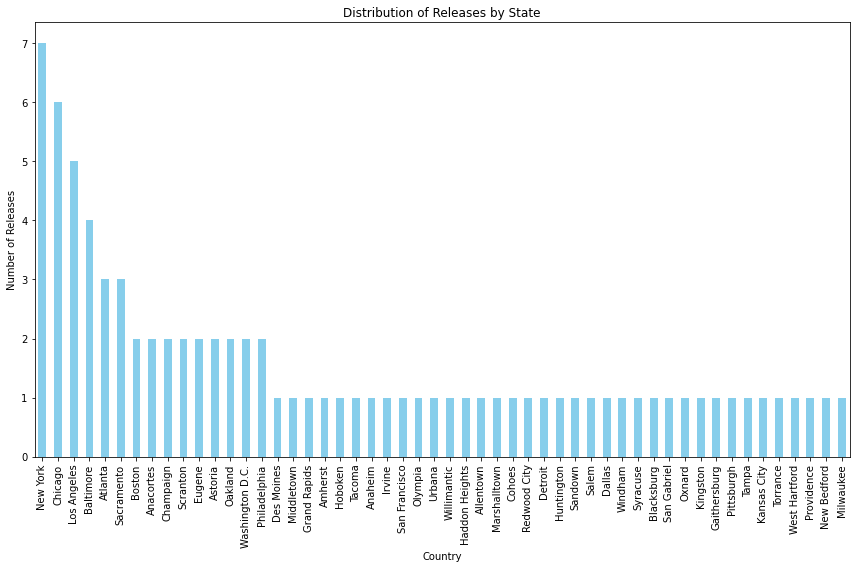

In [25]:
city_counts = df_final_no_artist_dupes_USA['City'].value_counts()

plt.figure(figsize=(12, 8))
city_counts.plot(kind='bar', color='skyblue')

# Adding labels and title
plt.xlabel('Country')
plt.ylabel('Number of Releases')
plt.title('Distribution of Releases by State')

# Rotate x-axis labels for better readability
plt.xticks(rotation=90)

# Display the plot
plt.tight_layout()
plt.show()

As I suspected. NYC is huge and dominates NY State. Same with Chicago. CA is represented here not jsut by LA, but the LA suburbs, exurbs, and a few northern CA cities. You can kind of see the same distribution with PA, since there are a few large population centers in that state. Baltimore dominates MD, so its not surprising to see that so high up.

## Incorporating a SQL database

For fun, let's see if we can match any of our releases to reviews from Pitchfork. This database is available on kaggle and contains over 18,000 reviews published by the outlet. This will give us some more numerical data to work with.

In [26]:
import sqlite3

reviews_path = '/Users/Nadim/Documents/Python/database.sqlite'
conn = sqlite3.connect(reviews_path)

pd.read_sql_query("SELECT * FROM sqlite_master", conn)

,type,name,tbl_name,rootpage,sql
0,table,reviews,reviews,2,"CREATE TABLE reviews (\n\treviewid INTEGER,\n\..."
1,table,artists,artists,3,"CREATE TABLE artists (\n\treviewid INTEGER, ar..."
2,table,genres,genres,4,"CREATE TABLE genres (\n\treviewid INTEGER, gen..."
3,table,labels,labels,5,"CREATE TABLE labels (\n\treviewid INTEGER, lab..."
4,table,years,years,6,"CREATE TABLE years (\n\treviewid INTEGER, year..."
5,table,content,content,7,"CREATE TABLE content (\n\treviewid INTEGER, co..."


We want the review scores, so I'm guessing its in the reviews table.

In [27]:
reviews = pd.read_sql_query("SELECT * FROM reviews", conn)
reviews.head()

,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year
0,22703,mezzanine,massive attack,http://pitchfork.com/reviews/albums/22703-mezz...,9.3,0,nate patrin,contributor,2017-01-08,6,8,1,2017
1,22721,prelapsarian,krallice,http://pitchfork.com/reviews/albums/22721-prel...,7.9,0,zoe camp,contributor,2017-01-07,5,7,1,2017
2,22659,all of them naturals,uranium club,http://pitchfork.com/reviews/albums/22659-all-...,7.3,0,david glickman,contributor,2017-01-07,5,7,1,2017
3,22661,first songs,"kleenex, liliput",http://pitchfork.com/reviews/albums/22661-firs...,9.0,1,jenn pelly,associate reviews editor,2017-01-06,4,6,1,2017
4,22725,new start,taso,http://pitchfork.com/reviews/albums/22725-new-...,8.1,0,kevin lozano,tracks coordinator,2017-01-06,4,6,1,2017


Great. I want to explore this database a bit...

In [28]:
pd.read_sql_query("SELECT MAX(pub_year) FROM reviews", conn)

,MAX(pub_year)
0,2017


In [29]:
pd.read_sql_query("SELECT MIN(pub_year) FROM reviews", conn)

,MIN(pub_year)
0,1999


So we are missing data beyond 2017, which isn't ideal but thankfully most of our releasees are pre-2017.

In [30]:
phil = pd.read_sql_query("SELECT title, artist, score, best_new_music, pub_year FROM reviews WHERE artist = 'mount eerie' OR artist = 'the microphones' ORDER BY pub_year ASC", conn)
phil

,title,artist,score,best_new_music,pub_year
0,"it was hot, we stayed in the water",the microphones,9.2,0,2000
1,blood,the microphones,8.2,0,2001
2,"the glow, pt. 2",the microphones,9.2,0,2001
3,song islands,the microphones,7.2,0,2002
4,mount eerie,the microphones,8.9,1,2003
5,seven new songs of mount eerie,mount eerie,7.8,0,2004
6,live in japan,the microphones,6.1,0,2004
7,"""singers""",mount eerie,6.8,0,2005
8,no flashlight,mount eerie,5.0,0,2005
9,mount eerie pts. 6 & 7,mount eerie,7.1,0,2007


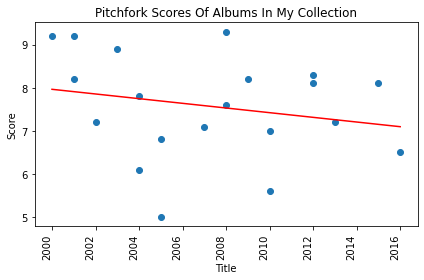

In [31]:
import numpy as np

phil_sorted = phil.sort_values('pub_year')

z = np.polyfit(phil_sorted['pub_year'], phil_sorted['score'], 1)
p = np.poly1d(z)

plt.plot(phil_sorted['pub_year'],phil_sorted['score'],'o')
plt.plot(phil_sorted['pub_year'], p(phil_sorted['pub_year']), 'r-', label='Trend Line')
plt.xticks(rotation=90, ha='right')
plt.title('Pitchfork Scores Of Albums In My Collection')
plt.xlabel('Title')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

Phil Eleverum's music is generally well reviewed. It's interesting to see the trend here, especially because some of his releases post-Sauna have been quite acclaimed and would make this fit look a lot different.

In [32]:
TA = pd.read_sql_query("SELECT * FROM reviews WHERE artist LIKE 'touch%' ORDER BY pub_year ASC", conn)
TA

,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year
0,18598,is survived by,touch amor,http://pitchfork.com/reviews/albums/18598-touc...,8.0,0,ian cohen,contributor,2013-10-04,4,4,10,2013
1,22359,stage four,touch amor,http://pitchfork.com/reviews/albums/22359-touc...,8.1,0,zoe camp,contributor,2016-09-16,4,16,9,2016


This is interesting. Touché Amoré is a band with special characters in the name. I had a hard time finding them in the database until I realized that the letters with the special characters have simply been omitted! Good to know...

In [33]:
gbye = pd.read_sql_query("SELECT * FROM reviews WHERE artist LIKE 'godspeed%' ORDER BY pub_year ASC", conn)
gbye

,reviewid,title,artist,url,score,best_new_music,author,author_type,pub_date,pub_weekday,pub_day,pub_month,pub_year
0,3489,lift your skinny fists like antennas to heaven,godspeed you! black emperor,http://pitchfork.com/reviews/albums/3489-lift-...,9.0,0,brent s. sirota,None,2000-10-25,2,25,10,2000
1,3487,yanqui u.x.o.,godspeed you! black emperor,http://pitchfork.com/reviews/albums/3487-yanqu...,5.6,0,ryan schreiber,editor-in-chief,2002-10-27,6,27,10,2002
2,17283,allelujah! don't bend! ascend!,godspeed you! black emperor,http://pitchfork.com/reviews/albums/17283-alle...,9.3,1,mark richardson,executive editor,2012-10-15,0,15,10,2012
3,20334,"asunder, sweet and other distress",godspeed you! black emperor,http://pitchfork.com/reviews/albums/20334-asun...,7.6,0,mark richardson,executive editor,2015-04-01,2,1,4,2015


Looks like punctuation marks are present!

I definitely want to grab the score column, as well as best_new_music, and maybe pub_year? We will use the title and artist columns to join into our dataset, but first we need to make sure the words are capitalized properly.

In [34]:
df_reviews = pd.read_sql_query("SELECT title,artist,score,best_new_music,pub_year FROM reviews", conn)

df_reviews.columns = [col.capitalize() for col in df_reviews.columns]
df_reviews['Artist'] = df_reviews['Artist'].str.title()
df_reviews['Title'] = df_reviews['Title'].str.title()

df_reviews.loc[(df_reviews['Artist'] == 'Touch Amor'), 'Artist'] = 'Touché Amoré'

In [35]:
vinyl_reviews = df_final_no_title_dupes.merge(df_reviews, how='inner', on = ['Title','Artist'])
vinyl_reviews = vinyl_reviews.sort_values('Artist')

Let's do a simple scatter showing the review score for each release, plotted with the average review score across just these releases. We can also add the average review score for ALL pitchfork review scores.

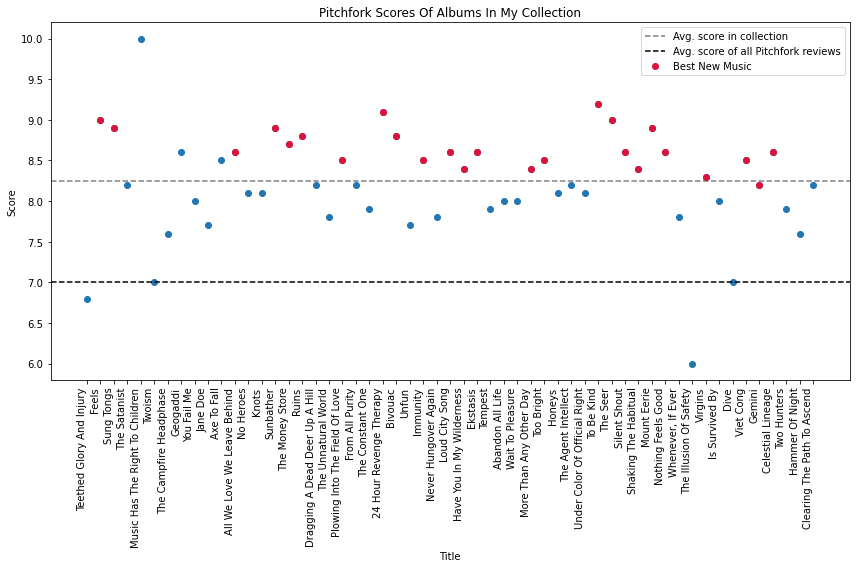

In [36]:
avg_score = vinyl_reviews['Score'].mean()
avg_score_ALL = pd.read_sql_query("SELECT AVG(score) FROM reviews", conn)

bnm = vinyl_reviews[vinyl_reviews['Best_new_music'] == 1]

plt.figure(figsize=(12, 8))

plt.plot(vinyl_reviews['Title'],vinyl_reviews['Score'],'o')
plt.axhline(avg_score, color='gray', linestyle='--', linewidth=1.5, label = 'Avg. score in collection')
plt.axhline(avg_score_ALL.loc[0][0], color='black', linestyle='--', linewidth=1.5, label = 'Avg. score of all Pitchfork reviews')
plt.plot(bnm['Title'], bnm['Score'], 'o', color='crimson', label='Best New Music')
plt.xticks(rotation=90, ha='right')
plt.title('Pitchfork Scores Of Albums In My Collection')
plt.xlabel('Title')
plt.ylabel('Score')
plt.legend()
plt.tight_layout()
plt.show()

Looks like my collection generally falls in the above average range of scores Pitchfork has given.

Let's see if we can learn about subgenres and their average review scores. We'll apply the same processing we did previously when we looked at genres and styles. Ideally we'd have many more releases to work with here to better justify the "average" we are taking.

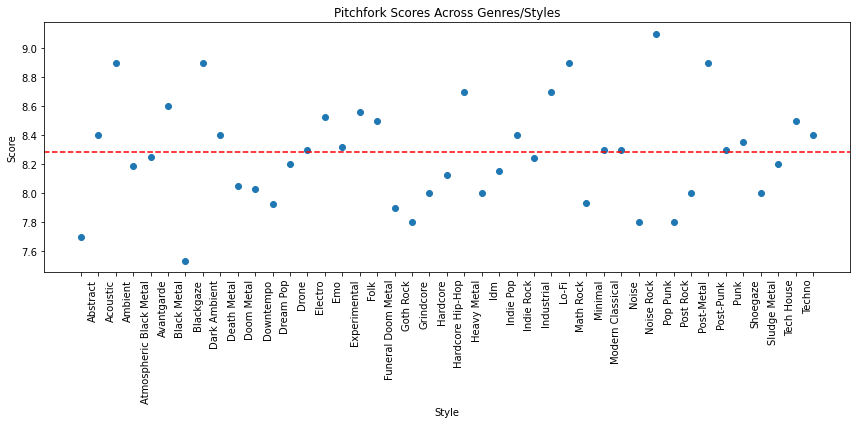

In [37]:
df_style = vinyl_reviews.dropna(subset=['Styles']).copy()
df_style['Styles'] = df_style['Styles'].str.replace('&', ',')  # Optional: replace '&' with comma
df_style['Styles'] = df_style['Styles'].str.split(',')

df_style['Styles'] = df_style['Styles'].apply(lambda styles: [s.strip() for s in styles])

df_exploded = df_style.explode('Styles')

df_exploded['Styles'] = df_exploded['Styles'].str.title()

style_scores = df_exploded.groupby('Styles').agg(
    avg_score=('Score', 'mean'),
).reset_index()

avg_style_score = style_scores['avg_score'].mean()

plt.figure(figsize=(12, 6))

plt.plot(style_scores['Styles'],style_scores['avg_score'],'o')
plt.axhline(avg_style_score, color='red', linestyle='--', linewidth=1.5, label = 'Avg. score in collection')
plt.xticks(rotation=90, ha='right')
plt.title('Pitchfork Scores Across Genres/Styles')
plt.xlabel('Style')
plt.ylabel('Score')
plt.tight_layout()
plt.show()

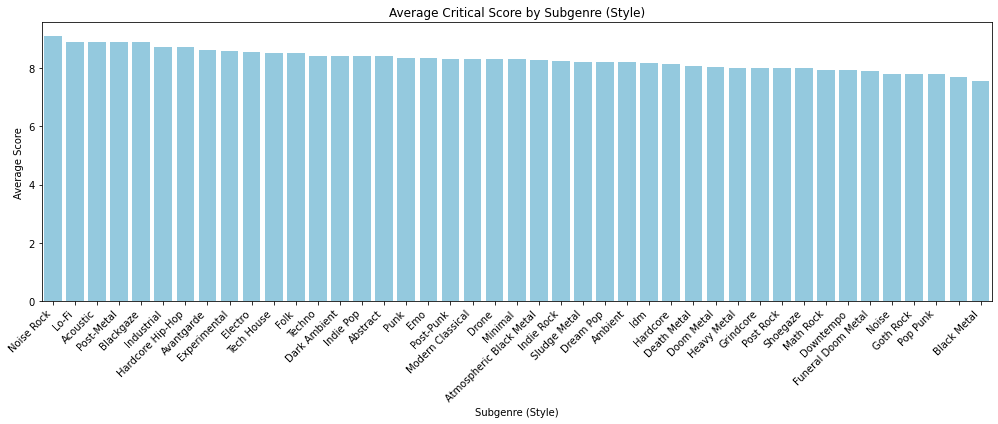

In [38]:
import seaborn as sns

style_scores = style_scores.sort_values(by='avg_score', ascending=False)

plt.figure(figsize=(14, 6))
sns.barplot(data=style_scores, x='Styles', y='avg_score', color = 'skyblue')

plt.xticks(rotation=45, ha='right')
plt.title('Average Critical Score by Subgenre (Style)')
plt.xlabel('Subgenre (Style)')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

Taking this at face value, it seems like Pitchfork tends to score noiser, more experimental music higher than more established genres. I'm also seeing a trend where metal is less preferred compared to other genres. Is there a geographical aspect to this? Let's look at the USA again.

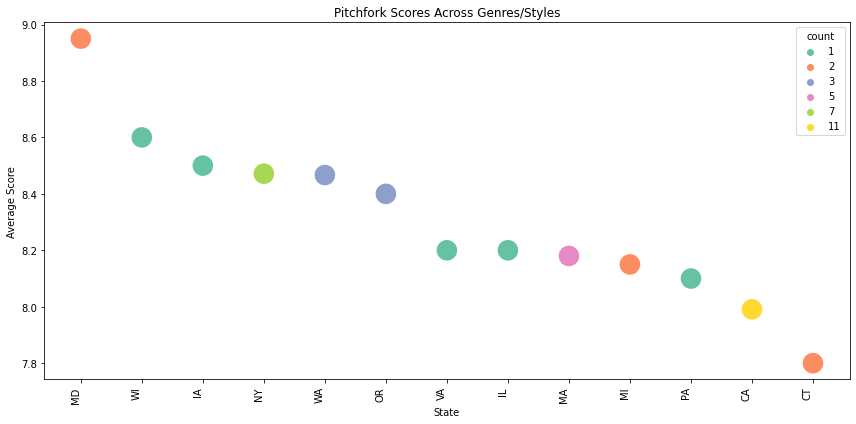

In [39]:
artist_scores = vinyl_reviews.groupby(['State','Country']).agg(
    avg_score=('Score', 'mean'),
    count=('Score', 'count')
).reset_index().sort_values(by='avg_score', ascending=False)

artist_scores = artist_scores[artist_scores['Country'] == 'USA']

plt.figure(figsize=(12, 6))

sns.scatterplot(data=artist_scores, x='State', y='avg_score', hue = 'count', palette = 'Set2', s = 500)
plt.xticks(rotation=90, ha='right')
plt.title('Pitchfork Scores Across Genres/Styles')
plt.xlabel('State')
plt.ylabel('Average Score')
plt.tight_layout()
plt.show()

At face value, Pitchfork really loves music from MD! I colored the points based on the number of reviews used to form the average. Obviously, an average based on one data point is not very useful, so this data can't really be taken too seriously.